# Big Mart Sales Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn import metrics

Data Collection & Analysis

In [11]:
# load csv file 
bigMart_dataset = pd.read_csv('Train.csv')
bigMart_dataset.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [12]:
bigMart_dataset['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [13]:
bigMart_dataset['Item_Fat_Content'] = bigMart_dataset['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

In [14]:
bigMart_dataset['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [15]:
# no. of data points & no. of features
bigMart_dataset.shape

(8523, 12)

In [16]:
# Getting some information about the dataset
bigMart_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB


Categorical Features: <br>
- Item_Identifier <br>
- Item_Fat_Content <br>
- Item_Type <br>
- Outlet_Identifier <br> 
- Outlet_Size <br>
- Outlet_Location_Type <br>
- Outlet_Type 

In [17]:
# Checking for missing values 
bigMart_dataset.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Handling the missing value 

In [18]:
# mean value of 'Item_Weight' column  
bigMart_dataset['Item_Weight'].mean()

np.float64(12.857645184135977)

In [23]:
# Filling the missing value in 'Item_Weight' column  with mean value
bigMart_dataset.fillna(
    {'Item_Weight': bigMart_dataset['Item_Weight'].mean()},
    inplace=True
)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [34]:
# Replacing the missing value in 'Outlet_Size' with mode
mode_of_outlet_size = (
    bigMart_dataset.groupby('Outlet_Type')['Outlet_Size']
    .agg(lambda x: x.mode().iloc[0])
)

print(mode_of_outlet_size)

Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: str


In [38]:
missing_value = bigMart_dataset['Outlet_Size'].isnull()
missing_value

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool

In [37]:
bigMart_dataset.loc[missing_value, 'Outlet_Size'] = (
    bigMart_dataset.loc[missing_value, 'Outlet_Type']
    .map(mode_of_outlet_size)
)

In [39]:
bigMart_dataset.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

Data Analysis

In [ ]:
# Statistical measures about the data
bigMart_dataset.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


Numerical Features

In [41]:
sns.set()

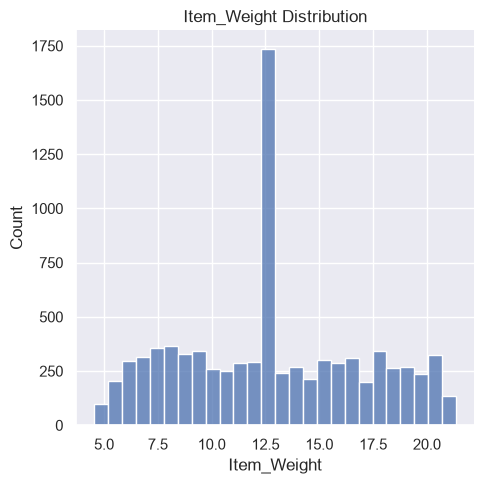

In [57]:
# item_weight distribution 
plt.Figure(figsize=(6,6))
sns.displot(bigMart_dataset['Item_Weight'])
plt.title('Item_Weight Distribution')
plt.tight_layout() 
plt.show()

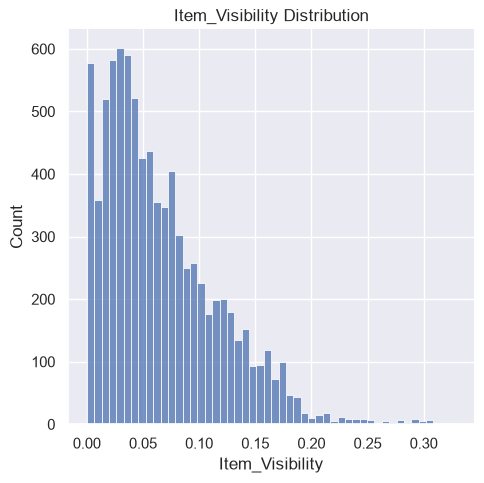

In [58]:
# Item_Visibility distribution 
plt.Figure(figsize=(6,6))
sns.displot(bigMart_dataset['Item_Visibility'])
plt.title('Item_Visibility Distribution')
plt.tight_layout() 
plt.show()

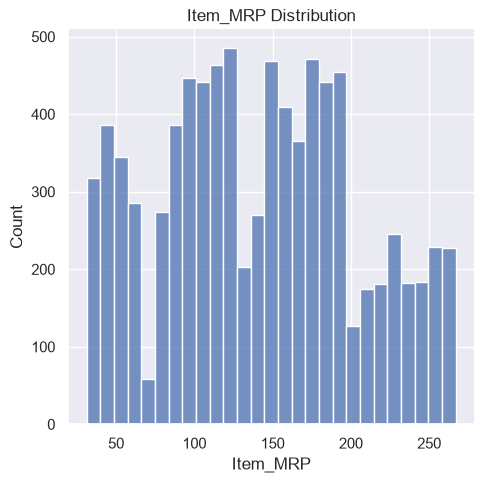

In [59]:
# Item_MRP distribution 
plt.Figure(figsize=(6,6))
sns.displot(bigMart_dataset['Item_MRP'])
plt.title('Item_MRP Distribution')
plt.tight_layout() 
plt.show()

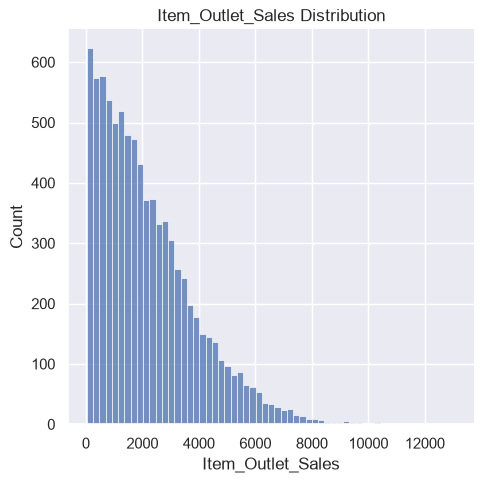

In [60]:
# Item_Outlet_Sales distribution 
plt.Figure(figsize=(6,6))
sns.displot(bigMart_dataset['Item_Outlet_Sales'])
plt.title('Item_Outlet_Sales Distribution')
plt.tight_layout() 
plt.show()

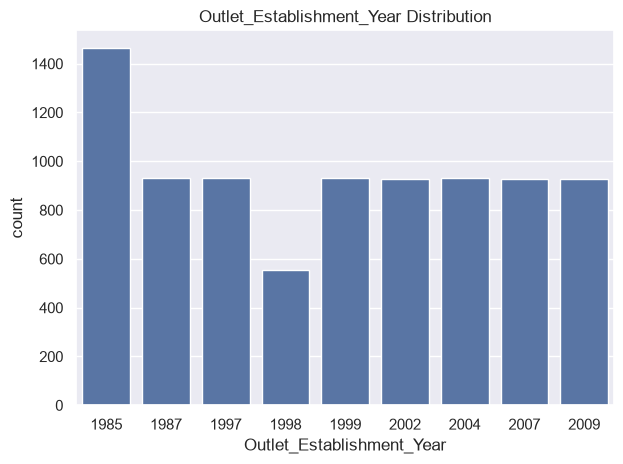

In [61]:
# Outlet_Establishment_Year distribution 
plt.Figure(figsize=(6,6))
sns.countplot(x='Outlet_Establishment_Year', data=bigMart_dataset)
plt.title('Outlet_Establishment_Year Distribution')
plt.tight_layout() 
plt.show()

Categorical Features

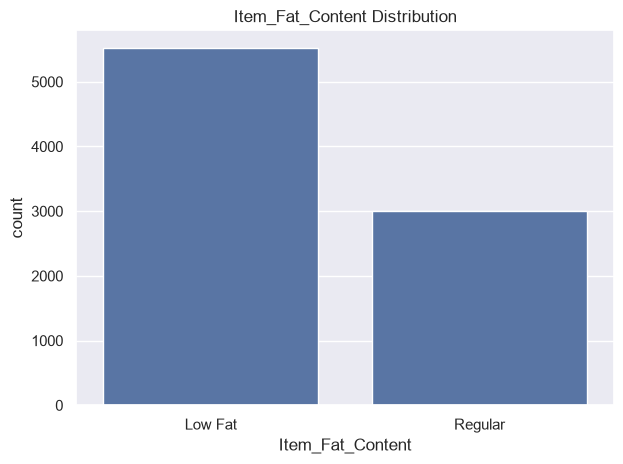

In [56]:
# Item_Fat_Content distribution 
plt.Figure(figsize=(6,6))
sns.countplot(x='Item_Fat_Content', data=bigMart_dataset)
plt.title('Item_Fat_Content Distribution')
plt.tight_layout() 
plt.show()

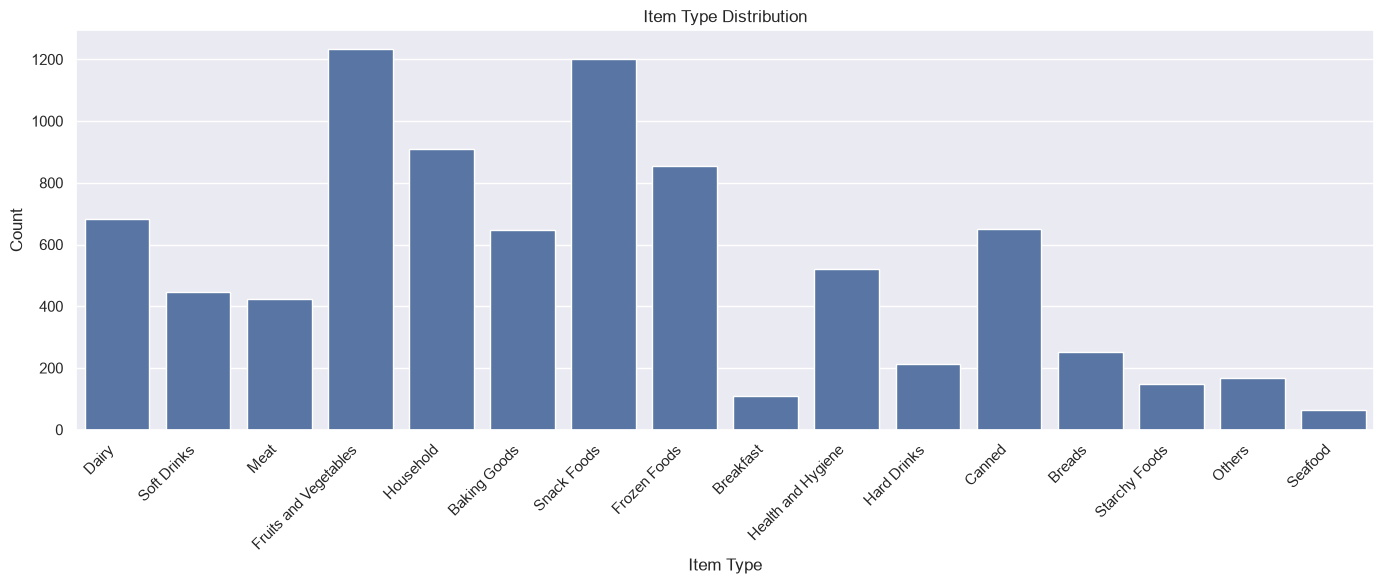

In [ ]:
# Item_Type distribution 
plt.figure(figsize=(14,6))
sns.countplot(x='Item_Type', data=bigMart_dataset)
plt.xticks(rotation=45, ha='right')   # Labels rotate honge
plt.xlabel('Item Type')
plt.ylabel('Count')
plt.title('Item Type Distribution')
plt.tight_layout()    # Labels cut nahi honge
plt.show()

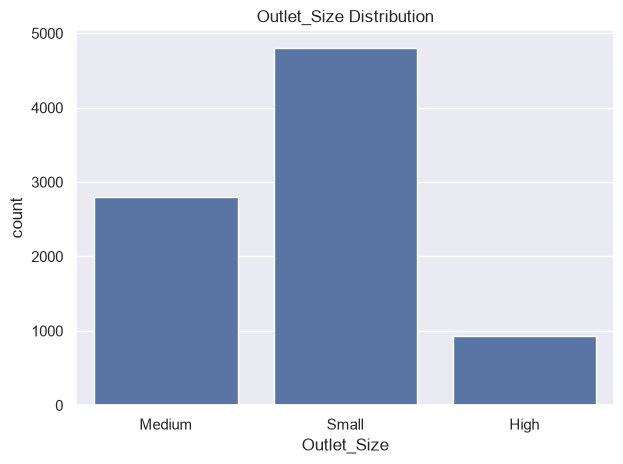

In [62]:
# Outlet_Size distribution 
plt.Figure(figsize=(6,6))
sns.countplot(x='Outlet_Size', data=bigMart_dataset)
plt.title('Outlet_Size Distribution')
plt.tight_layout() 
plt.show()

Label Encoding 

In [64]:
encoder = LabelEncoder()

In [65]:
bigMart_dataset['Item_Identifier'] = encoder.fit_transform(bigMart_dataset['Item_Identifier'])

bigMart_dataset['Item_Fat_Content'] = encoder.fit_transform(bigMart_dataset['Item_Fat_Content'])

bigMart_dataset['Item_Type'] = encoder.fit_transform(bigMart_dataset['Item_Type'])

bigMart_dataset['Outlet_Identifier'] = encoder.fit_transform(bigMart_dataset['Outlet_Identifier'])

bigMart_dataset['Outlet_Size'] = encoder.fit_transform(bigMart_dataset['Outlet_Size'])

bigMart_dataset['Outlet_Location_Type'] = encoder.fit_transform(bigMart_dataset['Outlet_Location_Type'])

bigMart_dataset['Outlet_Type'] = encoder.fit_transform(bigMart_dataset['Outlet_Type'])


In [66]:
bigMart_dataset.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


Spliting features and Target

In [67]:
X = bigMart_dataset.drop('Item_Outlet_Sales', axis=1)
Y = bigMart_dataset['Item_Outlet_Sales']

In [69]:
print('X value: ', X)

X value:        Item_Identifier  Item_Weight  Item_Fat_Content  Item_Visibility  \
0                 156        9.300                 0         0.016047   
1                   8        5.920                 1         0.019278   
2                 662       17.500                 0         0.016760   
3                1121       19.200                 1         0.000000   
4                1297        8.930                 0         0.000000   
...               ...          ...               ...              ...   
8518              370        6.865                 0         0.056783   
8519              897        8.380                 1         0.046982   
8520             1357       10.600                 0         0.035186   
8521              681        7.210                 1         0.145221   
8522               50       14.800                 0         0.044878   

      Item_Type  Item_MRP  Outlet_Identifier  Outlet_Establishment_Year  \
0             4  249.8092             

In [70]:
print('Y value: ', Y)

Y value:  0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64


Splitting the data into training and testing 

In [71]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [72]:
print(X.shape, X_train.shape, X_test.shape)

(8523, 11) (6818, 11) (1705, 11)


Machine Learning Model Training <br>
XGBoost Regressor

In [73]:
regressor = XGBRegressor()

In [74]:
regressor.fit(X_train, Y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Evalution

In [75]:
# prediction on training data
training_data_prediction = regressor.predict(X_train) 

In [77]:
# R squared value
r2_train = metrics.r2_score(Y_train, training_data_prediction)
print("R squared score value: ", r2_train)

R squared score value:  0.8750519939334624


In [78]:
# prediction on testing data
testing_data_prediction = regressor.predict(X_test) 

In [79]:
# R squared value
r2_test = metrics.r2_score(Y_test, testing_data_prediction)
print("R squared score value: ", r2_test)

R squared score value:  0.5155979721907443
